# Project Motivation

**Task** - the task is a to approximate a smooth non-linear function on a bounded 2D domain

Essentially this is a supervised regression task

As this project is for learning purposes rather pure practicality, we will be using a neural network even though there are more efficient methods of function interpolation.

### Why, can we use a neural network?
-- NEED TO ADD THAT WE CAN DO THIS USING UAT


Before we look at model architecture, training and so on, let's take a look at the data.

## Data Generation

For this project we will create synthetic data.
Here is the methodology :

We have some known smooth and non-linear function $f : [a,b]^2 \to \mathbb{R} , f(x,y)$   
where $a,b\in\mathbb{R}$

To generate the dataset, we take $n$ points $(x,y)\in[a,b]^2$
Then, we evaluate the function at these points and add some noise  
This gives us : $z_{i} = f(x_{i},y_{i}) + \epsilon_{i}\;\;1\leq i\leq n$ where $\epsilon_{i}\sim N(0,\sigma^2)\;\;i.d.d$  
This gives us the final dataset $\mathbf{D}=\{(x_{i} , y_{i} , z_{i}) \}_{i=1}^n$

This is implemented in the code below

So now we have our dataset $\mathbf{D}$, we can begin to think about the model and its implementation.

We need to : 

1) Choose a model
2) Choose a loss function
3) Choose weights that makes F a close approximation of the target function

#### (1) Choosing a model
We have already decided to use a neural network but we need to think about its structure.
For now, we will consider a simple Feed-Forward Network.

##### Feed-Forward Neural Network
<img src="fnn_diagram.png" alt="Feed-Forward Neural Network Diagram"/>

I have drawn this graph to show the general structure of an FNN.

An FNN simply consists of a set of "neurons" or "nodes" (taking inspiration from neurons in the brain).

These are modelled to be basic units of computation.
Typically, each neuron performs a weighted sum on its inputs and then adds some bias. To allow a network to capture more complex patterns, we then introduce non-linearity by applying a post activation function, giving a final output.
  
We then group a some of these neurons together, forming what we call a "layer".  
Thinking about a network in terms of its layers makes it easier when it comes to implementation.

We then take some these layers to form the network as shown above.  
The input layer just refers to the information we input into the network and does not actually perform any computation.  
The intermediate layers are called "hidden" because a user cannot directly interact with them. They perform most/all of the computation.  
Finally, we have the output layer which again doesn't perform any computation and is just the output of the network.  

How is everything connected?
Generally in an FNN, each neuron passes its output to every node in the next layer. This means that the network is "fully" connected.  
  
In different models, layers might not be sequentially arranged, the network might not be fully connected, and other modifications may be added. Additionally, we can make adjustments to model's architecture to improve the model's performance. 

How do we implement this/represent this mathematically?
  
*for convenience, i will explain everything in real numbers, but we can use different objects and so forth.*  
Representing a neuron:   
Suppose, we have $n$ inputs with the $i^{th}$ input, $x_i\in\mathbb{R}$ having weight $w_i\in\mathbb{R}$.  
We can then represent the weighted sum as $$\sum_{i=1}^{n}w_i x_i$$  
We can then add a bias term $b\in\mathbb{R}$, and then apply some activation function $\sigma:\mathbb{R}\to\mathbb{R}$
This gives us the output of a neuron $y\in\mathbb{R}$ as $$y=\sigma\big(\sum_{i=1}^n w_i x_i + b\big)$$


This is for one neuron, but what if we want to represent many neurons at once?  It would be quite messy to store and manage each neuron individually so we use linear algebra to help represent everything neatly.  
Notice that we can write the weighted sum for the $j^{th}$ node (with the $i^{th}$ input having a weight $w_ji$ for the $j^{th} node$) as $$\sum_{i=1}^n w_jix_i$$

This is actually the $i,j$ entry of some matrix multiplication $A\underline{x}$ where $A\in\mathbb{R}^{m \times n}$ and $\underline{x}\in\mathbb{R}^n$
# COMPLETE EXPLANATION

In [160]:
#Libraries needed

import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd

In [161]:
rand = np.random.default_rng(42)

#Defining the values we talked about
a = -100
b = 100
n = int(1e3)

#Our target function f
def f(x,y):
    return x**2+y**2


xcoords = rand.uniform(low=a,high=b,size=(n,1))
ycoords = rand.uniform(low=a,high=b,size=(n,1))
noise = rand.normal(loc=0,scale=1,size=(n,1))
zcoords = f(xcoords,ycoords) + noise

dataset = np.concatenate((xcoords,ycoords,zcoords),axis=1)


#Simple scatter plot for visualisation
fig = px.scatter_3d(dataset,x=0,y=1,z=2)
fig.show()

In [162]:
def ReLu(x):
    return np.maximum(0,x)

def MSE(labels,predictions):
    loss = np.sum((predictions - labels)**2)
    loss = loss/predictions.shape[0]
    return loss

def RMSE(labels,predictions):
    loss = MSE(labels,predictions)
    return np.sqrt(loss)

In [163]:
#LayerWidths -> an arr storing the number of neurons in the (k+1)th layer (left to right)
#PostActFuncs -> an arr storing the post-act func of each layer
class network:
    def __init__(self, LayerWidths,PostActivationFuncs):
        self.LayerNum = len(LayerWidths)-1
        self.LayerWidths = LayerWidths
        self.PostActivationFuncs = PostActivationFuncs
        self.layers = []
        self.LayerOutputs = []
        for i in range(1,self.LayerNum+1):
            layeri= layer(LayerWidths[i-1],LayerWidths[i],PostActivationFuncs[i])
            self.layers.append(layeri)


    def ForwardPass(self,input):
        self.LayerOutputs.clear()
        for i in range(self.LayerNum):
           input = self.layers[i].compute(input)
           self.LayerOutputs.append(input)

        return input

class layer:
    def __init__(self,InputWidth,width,PostActFunc):
        self.width = width
        self.PostActFunc = PostActFunc
        self.InputWidth = InputWidth
        self.weights = np.zeros((InputWidth,width))#np.array(rand.uniform(low=-np.sqrt(6/InputWidth),high=np.sqrt(6/InputWidth),size=(InputWidth,width)))
        self.bias = np.zeros((1,width))#np.array(rand.uniform(low=-np.sqrt(6/InputWidth),high=np.sqrt(6/InputWidth),size=(1,width)))
        #stochatistcally initialise a matrix

    def compute(self,input):
        LinearComputation = input@self.weights + self.bias
        PostActComputation = self.PostActFunc(LinearComputation)
        return PostActComputation

In [164]:
#formed the netowrk
fnn = network([2,300,300,300,1],[lambda x : x,ReLu,ReLu,ReLu,lambda x : x])

In [165]:
#formatting coords for input

TestTrainSplit = 0.8
batches = 10
SplitIndex = int(TestTrainSplit*n)
TrainData  = dataset[:SplitIndex]
TestData = dataset[SplitIndex:]

TrainDataBatches = np.split(TrainData,batches)

In [166]:
def GradDesc(CurrVal,Gradient,LearningRate=0.001):
    return CurrVal - LearningRate*Gradient


In [ ]:
LossValues = [[] for i in range(batches)]
IterNum = 100
LearningRate = 0.1
for iteration in range(IterNum):

    BatchNum = np.random.randint(0,batches)

    CurrentBatch = TrainDataBatches[BatchNum]
    predictions = np.apply_along_axis(fnn.ForwardPass,1,CurrentBatch[:,:-1])

    loss = MSE(CurrentBatch[:,-1],predictions)
    print(f"epoch : {iteration}, loss : {loss}")
    LossValues[BatchNum].append(loss)

    a3 = fnn.LayerOutputs[2]
    a2 = fnn.LayerOutputs[1]
    a1 = fnn.LayerOutputs[0]

    da3dz3 = np.diag((a3 > 0).astype(float).reshape(a3.shape[1]))
    da2dz2 = np.diag((a2 > 0).astype(float).reshape(a2.shape[1]))
    da1dz1 = np.diag((a1 > 0).astype(float).reshape(a1.shape[1]))

    for i in range(CurrentBatch.shape[0]):
        dLdyi = 2/np.sqrt(CurrentBatch.shape[0]) * (predictions[i] - CurrentBatch[i,-1])

        #Layer 4
        W4 = fnn.layers[3].weights
        b4 = fnn.layers[3].bias


        # (1 x 1)
        dLdb4 = dLdyi
        fnn.layers[3].bias = GradDesc(b4,dLdb4,LearningRate)

        # (1 x 1) x (300 x 1) = 1 x 300
        dLdW4 = dLdyi * a3.T
        fnn.layers[3].weights = GradDesc(W4,dLdW4,LearningRate)

        # (1 x 1) x (1 x 300) = 1 x 300
        dLda3 = dLdyi * W4.T

        #Layer 3
        W3 = fnn.layers[2].weights
        b3 = fnn.layers[2].bias


        #  (1 x 300) x (300 x 300) = 1 x 300
        dLdz3 = dLda3 @ da3dz3

        # 1 x 300
        dLdb3 = dLdz3
        fnn.layers[2].bias = GradDesc(b3,dLdb3,LearningRate)

        # (300 x 1) x (1 x 300) = 300 x 300
        dLdW3 =  a2.T @  dLdz3
        fnn.layers[2].weights = GradDesc(W3,dLdW3,LearningRate)

        # (1 x 300) x (300 x 300) = 1 x 300
        dLda2 = dLdz3 @ W3.T

        #Layer 2
        W2 = fnn.layers[1].weights
        b2 = fnn.layers[1].bias


        #  (1 x 300) x (300 x 300) = 1 x 300
        dLdz2 = dLda2 @ da2dz2

        # 1 x 300
        dLdb2 = dLdz2
        fnn.layers[1].bias = GradDesc(b2,dLdb2,LearningRate)

        # (300 x 1) x (1 x 300) = 300 x 300
        dLdW2 =  a1.T @  dLdz2
        fnn.layers[1].weights = GradDesc(W2,dLdW2,LearningRate)

        # (1 x 300) x (300 x 300) = 1 x 300
        dLda1 = dLdz2 @ W2.T

        #Layer 1
        W1 = fnn.layers[0].weights
        b1 = fnn.layers[0].bias
        x = CurrentBatch[i,:-1].reshape(1,2)

        #  (1 x 300) x (300 x 300) = 1 x 300
        dLdz1 = dLda1 @  da1dz1

        # 1 x 300
        dLdb1 = dLdz1
        fnn.layers[0].bias = GradDesc(b1,dLdb1,LearningRate)

        # (2 x 1) x (1 x 300) = 2 x 300
        dLdW1 =  x.T @  dLdz1
        fnn.layers[0].weights = GradDesc(W1,dLdW1,LearningRate)










epoch : 0, loss : 71545.50845601471
epoch : 1, loss : 67790.11251747319
epoch : 2, loss : 74641.75077667704
epoch : 3, loss : 73527.20888834377
epoch : 4, loss : 79104.32394283611
epoch : 5, loss : 67973.41368065444
epoch : 6, loss : 73527.18981392997
epoch : 7, loss : 74641.7212333742
epoch : 8, loss : 72650.31619369559
epoch : 9, loss : 72650.31171041015
epoch : 10, loss : 74641.70378237669
epoch : 11, loss : 63729.66743384509
epoch : 12, loss : 72650.29501701123
epoch : 13, loss : 67790.04372052402
epoch : 14, loss : 67790.04108892223
epoch : 15, loss : 62353.34374786946
epoch : 16, loss : 67790.01477828994
epoch : 17, loss : 67973.33962100581
epoch : 18, loss : 63729.626273538255
epoch : 19, loss : 73527.11208211882
epoch : 20, loss : 74641.64628277121
epoch : 21, loss : 72650.24105618976
epoch : 22, loss : 67973.31524838094
epoch : 23, loss : 67973.31093050116
epoch : 24, loss : 67973.3066126017
epoch : 25, loss : 76932.242672804
epoch : 26, loss : 72650.22192041605
epoch : 27, lo

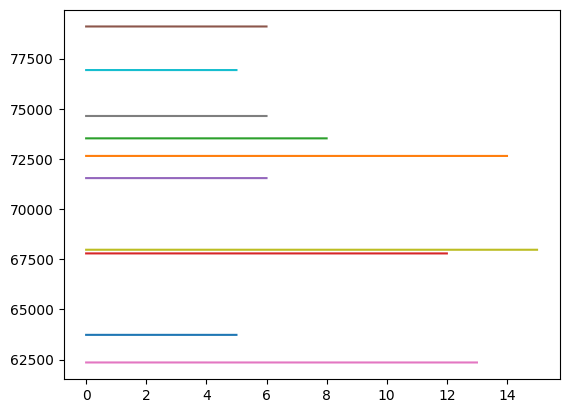

In [168]:
for i in range(len(LossValues)):
    plt.plot([j for j in range(len(LossValues[i]))],LossValues[i])
plt.show()

In [105]:
TestPredictions = np.apply_along_axis(fnn.ForwardPass,1,TestData[:,:-1])
RMSE(TestData[:,-1],TestPredictions)

np.float64(114826.62737830504)